In [20]:
#IMPORTS
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

01 - 8pts

Cargar el dataset adjunto de datos de vuelos 'flight_data.csv'

•A - Filtrar los vuelos con retrasos superiores a 30 minutos

•B - Escribir una función que clasifique los vuelos como 'A tiempo' (menos de 15 minutos), 'Retrasados' (menos de 60 minutos) o 'Cancelados' (más de 60 minutos), úsala para crear una nueva columna en el dataframe llamada 'Status'

•C - Visualizar el número total de vuelos por aerolínea, ordenados de forma descendente

•D - Visualizar la distribución de los retrasos de los vuelos mediante un histograma

•E - Filtrar los vuelos procedendes de 'JFK' y 'LAX', calcula la media y la mediana de los retrasos por aerolínea

•F - Dibujar un gráfico de barras con la media del retraso por aerolinea de 'JFK' y 'LAX' del punto anterior

•G - Mostrar las 3 compañias aéreas con la mediana de retrasos de vuelo más alta

•H - Filtrar los vuelos que hayan tenido un retraso por encima de la media de al menos la desviación estándar, y calcular el retraso medio de ellos


In [21]:
# •A - Filtrar los vuelos con retrasos superiores a 30 minutos
# Se establece la ruta del dataset
ruta = os.path.join("res", "flight_data.csv")
df = pd.read_csv(ruta, sep=",")

In [22]:
df_delay=df[df["Delay_Minutes"]>30].reset_index(drop=True, inplace=False)
df_delay

,Flight_Number,Origin,Destination,Airline,Delay_Minutes
0,FL8270,ATL,HND,American,147
1,FL1860,LAX,HND,United,163
2,FL6390,LAX,LHR,United,146
3,FL6191,ATL,HND,American,89
4,FL6734,DFW,SFO,British Airways,146
5,FL7265,LAX,HND,American,147
6,FL1466,LAX,LHR,United,95
7,FL5426,ATL,SFO,Delta,51
8,FL6578,LAX,CDG,Southwest,160
9,FL9322,LAX,HND,United,167


B - Escribir una función que clasifique los vuelos como 'A tiempo' (menos de 15 minutos), 'Retrasados' (menos de 60 minutos) o 'Cancelados' (más de 60 minutos), úsala para crear una nueva columna en el dataframe llamada 'Status'

In [23]:
def classify(celda):
    if celda<15:
        a ="A tiempo" 
    elif celda<60:
        a="Retrasados"
    else: 
        a="Cancelados"
    return a

In [24]:
df["status"]=df["Delay_Minutes"].apply(classify)

In [25]:
df['status']

0     Cancelados
1     Cancelados
2     Cancelados
3     Cancelados
4     Cancelados
5     Cancelados
6     Cancelados
7     Retrasados
8     Cancelados
9     Cancelados
10    Cancelados
11    Retrasados
12    Cancelados
13    Cancelados
14    Cancelados
15      A tiempo
16    Cancelados
17    Cancelados
18    Cancelados
19    Retrasados
20    Cancelados
21      A tiempo
22    Cancelados
23    Cancelados
24    Cancelados
25    Retrasados
26    Cancelados
27      A tiempo
28    Cancelados
29    Retrasados
30    Cancelados
31    Retrasados
32    Cancelados
33      A tiempo
34    Cancelados
35    Cancelados
36    Retrasados
37    Cancelados
38    Cancelados
39    Cancelados
40    Retrasados
41    Cancelados
42    Cancelados
43    Cancelados
44    Cancelados
45    Cancelados
46    Cancelados
47    Cancelados
48    Cancelados
49    Cancelados
Name: status, dtype: object

C - Visualizar el número total de vuelos por aerolínea, ordenados de forma descendente

In [33]:
df.groupby("Airline")["Flight_Number"].count().sort_values(ascending=False)

Airline
American           15
United             12
Southwest           9
Delta               8
British Airways     6
Name: Flight_Number, dtype: int64

D - Visualizar la distribución de los retrasos de los vuelos mediante un histograma

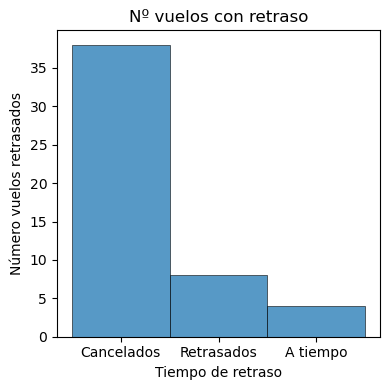

In [42]:
# Paso 1. Crear figura y varios ejes
fig, axs = plt.subplots(figsize=(4, 4))
# 2. Dibujar datos en cada eje
x=df["status"]
sns.histplot(x, linewidth=0.4, edgecolor='black') # O cualquier tipo de gráfico
# s= tamaño del punto
# linewidth = tamaño del borde del punto
# edgecolor = color del borde del punto

# 3. Configurar cada eje
axs.set_title("Nº vuelos con retraso")
axs.set_xlabel("Tiempo de retraso")
axs.set_ylabel("Número vuelos retrasados")

# Paso 4: ajustes del sistema de coordenadas
#axs.set_xlim(xmin, xmax)
#axs.set_ylim(ymin, ymax)

# Paso 5: ajustes globales
plt.tight_layout() # Evita solapamientos

# Paso 6: elementos auxiliares
#axs.legend()
#axs.grid(True)

# Paso 7: mostrar el gráfico
plt.show()


E - Filtrar los vuelos procedendes de 'JFK' y 'LAX', calcula la media y la mediana de los retrasos por aerolínea

In [59]:
df_filter=df[(df["Origin"]=="JFK") | (df["Origin"]=="LAX")]
df_describe=(df_filter.groupby("Origin").agg(Media=("Delay_Minutes", "mean"), Suma=("Delay_Minutes", "sum"), Cuenta=("Delay_Minutes", "count")))
df_describe



,Media,Suma,Cuenta
Origin,,,
JFK,87.750000,1053,12
LAX,119.636364,1316,11


F - Dibujar un gráfico de barras con la media del retraso por aerolinea de 'JFK' y 'LAX' del punto anterior

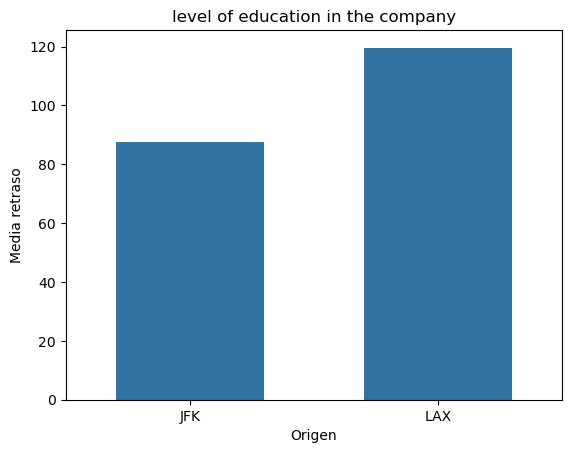

In [66]:
# Horizontal bar
fig, ax = plt.subplots()

# Example data
x=df_describe['Media']
sns.barplot(data=x, width=0.6)


ax.set_xlabel('Origen')
ax.set_ylabel('Media retraso')
ax.set_title('level of education in the company')
plt.show()


G - Mostrar las 3 compañias aéreas con la mediana de retrasos de vuelo más alta

In [75]:
df_g=df.groupby("Airline")["Delay_Minutes"].median()
df_g.sort_values(ascending=False, inplace=True)
df_g.head(3)

Airline
United             146.5
Delta              137.0
British Airways    113.0
Name: Delay_Minutes, dtype: float64

H - Filtrar los vuelos que hayan tenido un retraso por encima de la media de al menos la desviación estándar, y calcular el retraso medio de ellos

In [87]:
desv_est=df_g.std()
media=df_g.mean()
med_desv=media+desv_est
df_filt_desv=df[(df["Delay_Minutes"] > med_desv)]

media_retrasados=df_filt_desv["Delay_Minutes"].mean()

In [88]:
media_retrasados

np.float64(155.05263157894737)

02 - 2pt
•
Escribir una función 'prime_number' que cada vez que se invoque devuelva el siguiente número primo, empezando por el 2, hasta cualquier número infinito. Usando plain Python, sin ninguna librería. Primo es aquel número natural mayor que 1, que solo es divisible por 1 y por si mismo.

In [136]:
def prime_number():
    n = 2
    while True:
        es_primo = True
        for i in range(2, n):
            if n % i == 0:
                es_primo = False
                break
        if es_primo:
            yield n
        n+=1


In [150]:
gen=prime_number()

In [152]:
next(gen)

4